# Experiment 2026-07-08 — exploration-campaign sweep: linear vs nonlinear identifiers

This notebook studies the effect of **how many early campaigns are used for epsilon exploration** in the 20-campaign online setting.

The true environment is the **linear Laplacian** case. For each exploration count `0..10`, we run the same topology/initial-state seeds and compare:

- learned **linear Euler** identifier,
- learned **nonlinear λ-mix** identifier,
- oracle true-centrality baseline,
- uniform baseline,
- no-control baseline.

The main question is: **does adding exploration campaigns improve later exploitation enough to compensate for the budget spent on random/non-centrality-driven actions?**

Default training is the corrected practical online setting: `1_000` fit steps and `MAE stop = 5e-4` for `T_S = 0.05`. To test strict fitting, change `SWEEP_FIT_MAX_STEPS` and `SWEEP_FIT_MAE_STOP` in the config cell.


In [ ]:
from __future__ import annotations

import contextlib
import io
import math
import os
import random
import time
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "opinion_dynamics").exists():
            return p
    raise RuntimeError(
        "Could not find repo root containing opinion_dynamics/. "
        "Run this notebook from the repo or set REPO_ROOT manually."
    )


REPO_ROOT = find_repo_root()
print("REPO_ROOT:", REPO_ROOT)

import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control

# Reuse the already-working nonlinear online runner from the previous experiment.
from opinion_dynamics.experiments.online_single_shot import (
    run_single_shot_online_identification,
)

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_16316\727770809.py:13: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


REPO_ROOT: d:\Work\repos\RL\unknown_graph_networks


## Configuration

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using DEVICE:", DEVICE)

STUDY_DATE = "2026_07_08"
STUDY_NAME = "exploration_campaign_sweep_linear_vs_nonlinear"
RESULTS_DIR = REPO_ROOT / "opinion_dynamics" / "experiments" / "results" / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_DIR)

# True environment dynamics. Keep this linear so the linear identifier is correctly specified.
DYNAMICS = "laplacian"

# Default grid. For a smoke test, use TOPOLOGY_SEEDS = [3], INITIAL_PERMUTATION_SEEDS = [0].
# Full default: 11 exploration settings × 3 topology seeds × 3 x0 seeds × 2 learned models.
TOPOLOGY_SEEDS = [3, 4, 5]
INITIAL_PERMUTATION_SEEDS = [0, 1, 2]

# Paper-style graph/x0 constants.
N_AGENTS = 15
OMEGA = 1.0
U_BAR = 0.2

# Online campaign setting from the previous multitrial experiment.
NUM_CAMPAIGNS_TOTAL = 20          # campaign 0 is passive/no-control; campaigns 1..19 can receive budget
T_CAMPAIGN = 0.5
T_S = 0.05
TOTAL_CONTROLLED_BUDGET = 4.5
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS_TOTAL - 1)
LEARNED_POLICY_LAMBDA = 0.70

# Exploration sweep: campaigns 1..k are epsilon-mixed, then the rest are full exploitation.
EXPLORATION_CAMPAIGN_COUNTS = list(range(0, 11))
EPSILON_START = 1.0
EPSILON_END = 0.1

# Fixed fitting settings for the sweep.
# This is the corrected practical online setting for T_S = 0.05.
# For strict fitting, try SWEEP_FIT_MAX_STEPS = 50_000 and SWEEP_FIT_MAE_STOP = 1e-4.
LR = 1e-3
L2_LAMBDA = 0.0
SWEEP_FIT_MAX_STEPS = 1_000
SWEEP_FIT_MAE_STOP = 5e-4
SWEEP_FIT_BATCH_SIZE = 256
SWEEP_FIT_CHECK_EVERY = 200
IDENTIFIER_KW_NONLINEAR = {"hidden_dim": 16}

INITIAL_STATE_SEED_BASE = 920_000
TRAIN_SEED_BASE = 421_000
TRIAL_RNG_SEED_BASE = 731_000

KEEP_TRIAL_ARTIFACTS = False
SUPPRESS_FIT_LOGS = True

# Plot controls.
SELECT_EXPLORATION_COUNTS_FOR_TRAJECTORIES = [0, 5, 10]
HEATMAP_EXPLORATION_COUNTS = [0, 5, 10]


def make_epsilon_schedule(
    num_campaigns_total: int,
    exploration_campaigns: int,
    eps_start: float = 1.0,
    eps_end: float = 0.1,
) -> list[float]:
    """Campaign 0 is passive/no-control. Campaigns 1..exploration_campaigns linearly decay epsilon."""
    if num_campaigns_total < 1:
        raise ValueError("num_campaigns_total must be >= 1")
    exploration_campaigns = int(min(max(0, exploration_campaigns), num_campaigns_total - 1))
    schedule = [0.0]
    if exploration_campaigns > 0:
        if exploration_campaigns == 1:
            schedule.append(float(eps_start))
        else:
            schedule.extend(np.linspace(float(eps_start), float(eps_end), exploration_campaigns).tolist())
    schedule.extend([0.0] * (num_campaigns_total - len(schedule)))
    return [float(e) for e in schedule]


CONDITIONS = []
for k in EXPLORATION_CAMPAIGN_COUNTS:
    CONDITIONS.append({
        "condition": f"explore_{int(k):02d}",
        "condition_label": f"{int(k)} exploration campaigns",
        "fit_max_steps": int(SWEEP_FIT_MAX_STEPS),
        "fit_mae_stop": float(SWEEP_FIT_MAE_STOP),
        "fit_batch_size": int(SWEEP_FIT_BATCH_SIZE),
        "fit_check_every": int(SWEEP_FIT_CHECK_EVERY),
        "exploration_campaigns": int(k),
        "epsilon_schedule": make_epsilon_schedule(NUM_CAMPAIGNS_TOTAL, int(k), EPSILON_START, EPSILON_END),
    })

for cond in CONDITIONS:
    assert len(cond["epsilon_schedule"]) == NUM_CAMPAIGNS_TOTAL
    assert cond["epsilon_schedule"][0] == 0.0
    assert cond["exploration_campaigns"] <= NUM_CAMPAIGNS_TOTAL - 1

config_summary = {
    "study_name": STUDY_NAME,
    "dynamics": DYNAMICS,
    "topology_seeds": TOPOLOGY_SEEDS,
    "initial_permutation_seeds": INITIAL_PERMUTATION_SEEDS,
    "exploration_campaign_counts": EXPLORATION_CAMPAIGN_COUNTS,
    "n_conditions": len(CONDITIONS),
    "n_trials_per_condition": len(TOPOLOGY_SEEDS) * len(INITIAL_PERMUTATION_SEEDS),
    "n_learned_rollouts_expected": len(CONDITIONS) * len(TOPOLOGY_SEEDS) * len(INITIAL_PERMUTATION_SEEDS) * 2,
    "num_campaigns_total": NUM_CAMPAIGNS_TOTAL,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "total_time": NUM_CAMPAIGNS_TOTAL * T_CAMPAIGN,
    "B_campaign": B_CAMPAIGN,
    "total_controlled_budget": (NUM_CAMPAIGNS_TOTAL - 1) * B_CAMPAIGN,
    "lambda_mix": LEARNED_POLICY_LAMBDA,
    "epsilon_start": EPSILON_START,
    "epsilon_end": EPSILON_END,
    "fit_max_steps": SWEEP_FIT_MAX_STEPS,
    "fit_mae_stop": SWEEP_FIT_MAE_STOP,
}
config_summary


Using DEVICE: cpu
Results dir: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_08_exploration_campaign_sweep_linear_vs_nonlinear


{'study_name': 'exploration_campaign_sweep_linear_vs_nonlinear',
 'dynamics': 'laplacian',
 'topology_seeds': [3, 4, 5],
 'initial_permutation_seeds': [0, 1, 2],
 'exploration_campaign_counts': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'n_conditions': 11,
 'n_trials_per_condition': 9,
 'n_learned_rollouts_expected': 198,
 'num_campaigns_total': 20,
 't_campaign': 0.5,
 't_s': 0.05,
 'total_time': 10.0,
 'B_campaign': 0.23684210526315788,
 'total_controlled_budget': 4.5,
 'lambda_mix': 0.7,
 'epsilon_start': 1.0,
 'epsilon_end': 0.1,
 'fit_max_steps': 1000,
 'fit_mae_stop': 0.0005}

## Shared helpers

In [ ]:
def set_global_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def as_vector_max_u(max_u: Any, n: int) -> np.ndarray:
    u = np.asarray(max_u, dtype=float)
    if u.ndim == 0:
        return np.full(n, float(u), dtype=float)
    u = u.reshape(-1).astype(float)
    if u.shape != (n,):
        raise ValueError(f"max_u must be scalar or shape ({n},), got {u.shape}")
    return u


def sanitize_centrality(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    v = np.asarray(v, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if v.sum() < 0:
        v = -v
    v = np.maximum(v, 0.0)
    s = float(v.sum())
    if s <= eps:
        v = np.abs(v)
        s = float(v.sum())
    if s <= eps:
        return np.full_like(v, 1.0 / len(v))
    return v / s


def centrality_from_A(A: np.ndarray) -> np.ndarray:
    return sanitize_centrality(
        compute_eigenvector_centrality(compute_laplacian(np.asarray(A, dtype=float)))
    )


def make_paper_initial_opinions(n: int, permutation_seed: int) -> np.ndarray:
    rng = np.random.default_rng(INITIAL_STATE_SEED_BASE + int(permutation_seed))
    x = np.linspace(0.0, 1.0, int(n), dtype=float)
    return rng.permutation(x)


def set_initial_state(env: Any, x0: np.ndarray) -> None:
    x0 = np.asarray(x0, dtype=float).reshape(-1)
    if hasattr(env, "initial_opinions"):
        try:
            env.initial_opinions = x0.copy()
        except Exception:
            pass
    env.opinions = x0.copy()
    if hasattr(env, "state"):
        try:
            env.state = x0.copy()
        except Exception:
            pass


def clone_env_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    omega: float = OMEGA,
    u_bar: float = U_BAR,
    terminate_when_converged: bool = False,
) -> Any:
    n = int(env_template.num_agents)
    kwargs = dict(
        connectivity_matrix=np.array(env_template.connectivity_matrix, copy=True),
        num_agents=n,
        max_u=np.full(n, float(u_bar), dtype=float),
        desired_opinion=float(omega),
        t_campaign=float(t_campaign),
        t_s=float(t_s),
        dynamics_model=str(dynamics_model if dynamics_model is not None else getattr(env_template, "dynamics_model", "laplacian")),
        control_resistance=np.array(getattr(env_template, "control_resistance", np.zeros(n)), copy=True),
        max_steps=int(getattr(env_template, "max_steps", 10_000)),
        opinion_end_tolerance=float(getattr(env_template, "opinion_end_tolerance", 0.01)),
        control_beta=float(getattr(env_template, "control_beta", 0.4)),
        normalize_reward=bool(getattr(env_template, "normalize_reward", False)),
        terminal_reward=float(getattr(env_template, "terminal_reward", 0.0)),
        terminate_when_converged=bool(terminate_when_converged),
        seed=int(getattr(env_template, "seed", 0)) if getattr(env_template, "seed", None) is not None else None,
    )
    optional_attrs = [
        "fj_lambda", "fj_prejudice", "hk_epsilon", "hk_include_self",
        "nonlinear_beta", "repulsion_epsilon", "repulsion_strength",
    ]
    for attr in optional_attrs:
        if hasattr(env_template, attr):
            kwargs[attr] = getattr(env_template, attr)

    EnvCls = env_template.__class__
    try:
        return EnvCls(**kwargs)
    except TypeError:
        for attr in optional_attrs:
            kwargs.pop(attr, None)
        return EnvCls(**kwargs)


def make_base_env(topology_seed: int) -> Any:
    factory = EnvironmentFactory()
    env = factory.get_randomized_env(seed=int(topology_seed), dynamics_model=DYNAMICS)
    return clone_env_from_template(
        env,
        dynamics_model=DYNAMICS,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )


def pairs_from_intermediate(intermediate_states: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    inter = np.asarray(intermediate_states, dtype=float)
    return inter[:-1], inter[1:]


def normalize_scores(scores: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    s = np.asarray(scores, dtype=float).reshape(-1)
    s = np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0)
    s = np.maximum(s, 0.0)
    m = float(s.max()) if s.size else 0.0
    if m <= eps:
        return np.ones_like(s)
    return s / m


def waterfill_from_scores(scores: np.ndarray, max_u: np.ndarray, budget: float) -> np.ndarray:
    scores = np.asarray(scores, dtype=float).reshape(-1)
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    if scores.shape != max_u.shape:
        raise ValueError(f"scores and max_u shape mismatch: {scores.shape} vs {max_u.shape}")

    u = np.zeros_like(scores, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    if remaining <= 0:
        return u

    order = np.argsort(scores)[::-1]
    for i in order:
        if remaining <= 1e-12:
            break
        if scores[i] <= 0 and np.any(scores > 0):
            break
        assign = min(float(max_u[i]), remaining)
        if assign > 0:
            u[i] = assign
            remaining -= assign
    return u


def uniform_budget_action(max_u: np.ndarray, budget: float) -> np.ndarray:
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    n = max_u.size
    u = np.zeros(n, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    active = np.ones(n, dtype=bool)
    while remaining > 1e-12 and active.any():
        idxs = np.where(active)[0]
        share = remaining / len(idxs)
        progressed = False
        for i in idxs:
            add = min(share, float(max_u[i] - u[i]))
            if add > 0:
                u[i] += add
                remaining -= add
                progressed = True
            if u[i] >= max_u[i] - 1e-12:
                active[i] = False
        if not progressed:
            break
    return u


def step_env_collect(env: Any, action: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, np.ndarray]:
    x_next, reward, done, truncated, info = env.step(np.asarray(action, dtype=float))
    inter = info.get("intermediate_states", None)
    if inter is None:
        raise RuntimeError("env.step did not return info['intermediate_states']")
    return np.asarray(x_next, dtype=float), float(reward), bool(done), bool(truncated), np.asarray(inter, dtype=float)

In [ ]:
class PaperLinearGraphIdentifier(nn.Module):
    """Row-stochastic zero-diagonal linear Euler identifier."""

    def __init__(self, N: int, s: float, l2_lambda: float = 0.0, zero_diag: bool = True):
        super().__init__()
        self.N = int(N)
        self.s = float(s)
        self.l2_lambda = float(l2_lambda)
        self.zero_diag = bool(zero_diag)
        self.Theta = nn.Parameter(torch.zeros(self.N, self.N))
        nn.init.kaiming_uniform_(self.Theta, a=0.0)
        self.register_buffer("_diag_mask", 1.0 - torch.eye(self.N))
        self.last_fit_info = {}

    def A_hat(self) -> torch.Tensor:
        A = F.softmax(self.Theta, dim=1)
        if self.zero_diag:
            A = A * self._diag_mask
            rs = A.sum(dim=1, keepdim=True)
            rs = torch.where(rs > 0, rs, torch.ones_like(rs))
            A = A / rs
        return A

    def predict_next(self, x: torch.Tensor) -> torch.Tensor:
        A = self.A_hat()
        neighbor_avg = x @ A.T
        return x + self.s * (neighbor_avg - x)

    def loss(self, x: torch.Tensor, x_next: torch.Tensor):
        pred = self.predict_next(x)
        mse = F.mse_loss(pred, x_next)
        l2 = (self.Theta ** 2).sum()
        return mse + self.l2_lambda * l2, {"mse": mse.detach(), "l2": l2.detach()}


def train_paper_linear_identifier(
    model: PaperLinearGraphIdentifier,
    data_x: np.ndarray,
    data_x_next: np.ndarray,
    *,
    lr: float = LR,
    batch_size: int = SWEEP_FIT_BATCH_SIZE,
    max_steps: int = SWEEP_FIT_MAX_STEPS,
    mae_stop: float = SWEEP_FIT_MAE_STOP,
    fit_check_every: int = SWEEP_FIT_CHECK_EVERY,
    device: str = DEVICE,
    suppress_logs: bool = SUPPRESS_FIT_LOGS,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    model.to(device)
    X = torch.tensor(np.asarray(data_x, dtype=np.float32), dtype=torch.float32, device=device)
    Y = torch.tensor(np.asarray(data_x_next, dtype=np.float32), dtype=torch.float32, device=device)
    n = int(X.shape[0])
    if n == 0:
        raise ValueError("No training pairs provided.")

    opt = torch.optim.Adam(model.parameters(), lr=float(lr))
    stop_reason = "max_steps"
    last_mae = float("nan")
    t0 = time.perf_counter()

    for step in range(int(max_steps)):
        idx = torch.randint(0, n, (min(int(batch_size), n),), device=device)
        loss, _ = model.loss(X[idx], Y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % int(fit_check_every) == 0 or step == int(max_steps) - 1:
            with torch.no_grad():
                yhat = model.predict_next(X)
                mae = float((yhat - Y).abs().mean().item())
                last_mae = mae
            if (not suppress_logs) and (step % 2000 == 0 or mae <= mae_stop):
                print(f"[linear-fit] step={step} mae={mae:.5g} n_pairs={n}")
            if mae <= float(mae_stop):
                stop_reason = "mae_stop"
                break

    fit_time = time.perf_counter() - t0
    with torch.no_grad():
        A = model.A_hat().detach().cpu().numpy()
        yhat = model.predict_next(X)
        final_mae = float((yhat - Y).abs().mean().item())
        identity_mae = float((X - Y).abs().mean().item())

    info = {
        "steps_run": int(step + 1),
        "stop_reason": stop_reason,
        "train_mae": final_mae,
        "identity_mae": identity_mae,
        "model_over_identity": final_mae / (identity_mae + 1e-12),
        "n_pairs": n,
        "fit_time_sec": float(fit_time),
    }
    model.last_fit_info = info
    return A, info

## Rollout routines

In [ ]:
def rollout_fixed_policy_single_shot(
    env_template: Any,
    x0: np.ndarray,
    *,
    policy_name: str,
    v_policy: Optional[np.ndarray] = None,
    num_campaigns_total: int = NUM_CAMPAIGNS_TOTAL,
    B_campaign: float = B_CAMPAIGN,
    zero_first_campaign: bool = True,
) -> Dict[str, Any]:
    env = clone_env_from_template(env_template, terminate_when_converged=False)
    env.reset()
    set_initial_state(env, x0)

    states = [np.asarray(x0, dtype=float).copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []

    max_u = as_vector_max_u(env.max_u, env.num_agents)

    for k in range(int(num_campaigns_total)):
        if policy_name == "no_control" or (zero_first_campaign and k == 0):
            u = np.zeros(env.num_agents, dtype=float)
        elif policy_name == "uniform":
            u = uniform_budget_action(max_u, B_campaign)
        elif policy_name == "oracle_true_v":
            if v_policy is None:
                raise ValueError("v_policy is required for oracle_true_v")
            u, _ = centrality_based_continuous_control(env, B_campaign, v=v_policy)
        else:
            raise ValueError(f"Unknown policy_name={policy_name}")

        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))

        if done or trunc:
            break

    return {
        "policy": policy_name,
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
    }


def exploratory_linear_action(
    model: Optional[PaperLinearGraphIdentifier],
    x: np.ndarray,
    *,
    desired_opinion: float,
    max_u: np.ndarray,
    budget: float,
    epsilon: float,
    rng: np.random.Generator,
    device: str = DEVICE,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    x = np.asarray(x, dtype=float).reshape(-1)
    random_scores = rng.random(x.shape[0])

    if model is None:
        learned_scores = np.zeros_like(random_scores)
        v_hat = np.full_like(random_scores, 1.0 / len(random_scores), dtype=float)
        A_hat = np.zeros((len(random_scores), len(random_scores)), dtype=float)
    else:
        model.to(device)
        model.eval()
        with torch.no_grad():
            A_hat = model.A_hat().detach().cpu().numpy()
        v_hat = centrality_from_A(A_hat)
        learned_scores = v_hat * np.abs(float(desired_opinion) - x)

    eps = float(np.clip(epsilon, 0.0, 1.0))
    combined_scores = (1.0 - eps) * normalize_scores(learned_scores) + eps * normalize_scores(random_scores)
    action = waterfill_from_scores(combined_scores, max_u=max_u, budget=budget)

    info = {
        "epsilon": eps,
        "learned_scores": learned_scores,
        "random_scores": random_scores,
        "combined_scores": combined_scores,
        "learned_centrality": v_hat,
        "learned_matrix": A_hat,
    }
    return action, info


def run_single_shot_online_linear_identifier(
    env_template: Any,
    *,
    x0: np.ndarray,
    topology_seed: int,
    initial_seed: int,
    num_campaigns_total: int = NUM_CAMPAIGNS_TOTAL,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    B_campaign: float = B_CAMPAIGN,
    epsilon_schedule: Optional[Iterable[float]] = None,
    lr: float = LR,
    l2_lambda: float = L2_LAMBDA,
    fit_max_steps: int = SWEEP_FIT_MAX_STEPS,
    fit_mae_stop: float = SWEEP_FIT_MAE_STOP,
    fit_batch_size: int = SWEEP_FIT_BATCH_SIZE,
    fit_check_every: int = SWEEP_FIT_CHECK_EVERY,
    device: str = DEVICE,
    rng_seed: int = 0,
) -> Dict[str, Any]:
    env = clone_env_from_template(
        env_template,
        dynamics_model=DYNAMICS,
        t_campaign=t_campaign,
        t_s=t_s,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )
    if epsilon_schedule is None:
        epsilon_schedule = [0.0] * num_campaigns_total
    else:
        epsilon_schedule = list(epsilon_schedule)

    assert len(epsilon_schedule) == num_campaigns_total

    env.reset()
    set_initial_state(env, x0)

    N = int(env.num_agents)
    max_u = as_vector_max_u(env.max_u, N)

    train_seed = TRAIN_SEED_BASE + 10_000 * int(topology_seed) + 100 * int(initial_seed)
    set_global_seed(train_seed)
    rng = np.random.default_rng(int(rng_seed))

    eps_schedule = list(epsilon_schedule)
    if len(eps_schedule) < int(num_campaigns_total):
        eps_schedule = eps_schedule + [0.0] * (int(num_campaigns_total) - len(eps_schedule))

    state = np.asarray(x0, dtype=float).reshape(N)
    states = [state.copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []
    policy_infos = []
    A_hats = []
    v_hats = []
    fit_infos = []
    buf_x, buf_y = [], []
    model: Optional[PaperLinearGraphIdentifier] = None

    for k in range(int(num_campaigns_total)):
        if k == 0:
            action = np.zeros(N, dtype=float)
            policy_info = {"epsilon": np.nan, "phase": "passive_initial"}
        else:
            eps_k = float(eps_schedule[k])
            action, policy_info = exploratory_linear_action(
                model,
                state,
                desired_opinion=float(env.desired_opinion),
                max_u=max_u,
                budget=float(B_campaign),
                epsilon=eps_k,
                rng=rng,
                device=device,
            )
            policy_info["phase"] = "explore" if eps_k > 0 else "exploit"

        x_next, r, done, trunc, inter = step_env_collect(env, action)
        Xp, Yp = pairs_from_intermediate(inter)
        buf_x.append(Xp)
        buf_y.append(Yp)

        actions.append(action.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))
        policy_infos.append(policy_info)

        if model is None:
            model = PaperLinearGraphIdentifier(N=N, s=float(env.t_s), l2_lambda=l2_lambda, zero_diag=True)

        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)
        A_hat, fit_info = train_paper_linear_identifier(
            model,
            X,
            Y,
            lr=lr,
            batch_size=fit_batch_size,
            max_steps=fit_max_steps,
            mae_stop=fit_mae_stop,
            fit_check_every=fit_check_every,
            device=device,
            suppress_logs=SUPPRESS_FIT_LOGS,
        )
        v_hat = centrality_from_A(A_hat)

        fit_info = dict(fit_info, campaign=int(k))
        fit_infos.append(fit_info)
        A_hats.append(np.asarray(A_hat, dtype=float).copy())
        v_hats.append(v_hat.copy())

        state = np.asarray(x_next, dtype=float).copy()

        if done or trunc:
            break

    return {
        "policy": "online_linear_euler",
        "model": model,
        "x0": np.asarray(x0, dtype=float),
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "policy_infos": policy_infos,
        "A_hats": A_hats,
        "v_hats": v_hats,
        "fit_infos": fit_infos,
        "epsilon_schedule": np.asarray(eps_schedule[: len(actions)], dtype=float),
    }


def wrap_nonlinear_rollout(out: Dict[str, Any]) -> Dict[str, Any]:
    out = dict(out)
    out["policy"] = "online_nonlinear_lambda_mix"
    out["boundary_times"] = np.arange(len(out["states"]), dtype=float) * float(T_CAMPAIGN)
    return out

## Metrics and table helpers

In [ ]:
POLICY_LINEAR = "online_linear_euler"
POLICY_NONLINEAR = "online_nonlinear_lambda_mix"
POLICY_ORACLE = "oracle_true_v"
POLICY_UNIFORM = "uniform"
POLICY_NOCONTROL = "no_control"

POLICY_LABELS = {
    POLICY_LINEAR: "online linear Euler",
    POLICY_NONLINEAR: "online nonlinear λ-mix",
    POLICY_ORACLE: "oracle true-v",
    POLICY_UNIFORM: "uniform",
    POLICY_NOCONTROL: "no control",
}

PLOT_POLICIES = [POLICY_ORACLE, POLICY_LINEAR, POLICY_NONLINEAR, POLICY_UNIFORM, POLICY_NOCONTROL]


def final_consensus_error(states: np.ndarray, v_true: np.ndarray, omega: float = OMEGA) -> float:
    final_state = np.asarray(states, dtype=float)[-1]
    consensus_value = float(np.asarray(v_true, dtype=float).reshape(-1) @ final_state)
    return abs(float(omega) - consensus_value)


def rollout_mean_end(out: Dict[str, Any]) -> float:
    return float(np.asarray(out["states"], dtype=float)[-1].mean())


def trajectory_rows(
    *,
    topology_seed: int,
    initial_seed: int,
    policy: str,
    rollout: Dict[str, Any],
    v_true: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []
    states = np.asarray(rollout["states"], dtype=float)
    times = np.asarray(rollout["boundary_times"], dtype=float)
    trial_id = f"{DYNAMICS}|topo={topology_seed}|init={initial_seed}"
    for idx, (t, x) in enumerate(zip(times, states)):
        rows.append({
            "dynamics": DYNAMICS,
            "topology_seed": int(topology_seed),
            "initial_seed": int(initial_seed),
            "trial_id": trial_id,
            "policy": policy,
            "policy_label": POLICY_LABELS.get(policy, policy),
            "boundary_index": int(idx),
            "time": float(t),
            "mean_opinion": float(np.mean(x)),
            "min_opinion": float(np.min(x)),
            "max_opinion": float(np.max(x)),
            "consensus_value": float(np.asarray(v_true).reshape(-1) @ np.asarray(x).reshape(-1)),
        })
    return rows


def learned_identifier_metrics(
    *,
    model_name: str,
    learned: Dict[str, Any],
    A_true: np.ndarray,
    v_true: np.ndarray,
) -> Dict[str, Any]:
    A_hats = learned.get("A_hats", [])
    if model_name == POLICY_NONLINEAR:
        v_hats = learned.get("v_hats_lambda", []) or learned.get("v_hats_static", [])
    else:
        v_hats = learned.get("v_hats", [])

    if not A_hats or not v_hats:
        return {}

    A_final = np.asarray(A_hats[-1], dtype=float)
    v_final = np.asarray(v_hats[-1], dtype=float)
    v_errs = [float(np.sum(np.abs(np.asarray(vh, dtype=float) - v_true))) for vh in v_hats]

    last_fit = learned["fit_infos"][-1]
    return {
        "max_v_L1": float(max(v_errs)),
        "final_v_L1": float(np.sum(np.abs(v_final - v_true))),
        "A_MAE_final": float(np.mean(np.abs(A_final - A_true))),
        "A_Fro_final": float(np.linalg.norm(A_final - A_true, ord="fro")),
        "final_train_mae": float(last_fit["train_mae"]),
        "final_identity_mae": float(last_fit["identity_mae"]),
        "final_model_over_identity": float(last_fit["model_over_identity"]),
        "final_n_pairs": int(last_fit["n_pairs"]),
        "total_fit_time_sec": float(sum(info.get("fit_time_sec", info.get("fit_elapsed_s", 0.0)) for info in learned["fit_infos"])),
    }


def summarize_learned_trial(
    *,
    topology_seed: int,
    initial_seed: int,
    model_name: str,
    learned: Dict[str, Any],
    oracle: Dict[str, Any],
    uniform: Dict[str, Any],
    no_control: Dict[str, Any],
    A_true: np.ndarray,
    v_true: np.ndarray,
) -> Dict[str, Any]:
    delta = final_consensus_error(learned["states"], v_true)
    delta_oracle = final_consensus_error(oracle["states"], v_true)
    delta_uniform = final_consensus_error(uniform["states"], v_true)
    delta_noc = final_consensus_error(no_control["states"], v_true)

    mean_end = rollout_mean_end(learned)
    mean_oracle = rollout_mean_end(oracle)
    mean_uniform = rollout_mean_end(uniform)
    mean_noc = rollout_mean_end(no_control)

    row = {
        "dynamics": DYNAMICS,
        "topology_seed": int(topology_seed),
        "initial_seed": int(initial_seed),
        "trial_id": f"{DYNAMICS}|topo={topology_seed}|init={initial_seed}",
        "model": model_name,
        "model_label": POLICY_LABELS[model_name],
        "delta": float(delta),
        "delta_oracle": float(delta_oracle),
        "delta_uniform": float(delta_uniform),
        "delta_nocontrol": float(delta_noc),
        "suboptimality_vs_oracle_delta": float(delta - delta_oracle),
        "model_minus_uniform_delta": float(delta - delta_uniform),
        "model_minus_nocontrol_delta": float(delta - delta_noc),
        "mean_end": float(mean_end),
        "mean_oracle_end": float(mean_oracle),
        "mean_uniform_end": float(mean_uniform),
        "mean_nocontrol_end": float(mean_noc),
        "model_minus_oracle_mean_end": float(mean_end - mean_oracle),
        "model_minus_uniform_mean_end": float(mean_end - mean_uniform),
        "model_minus_nocontrol_mean_end": float(mean_end - mean_noc),
    }
    row.update(learned_identifier_metrics(model_name=model_name, learned=learned, A_true=A_true, v_true=v_true))
    return row


def fit_rows_from_rollout(
    *,
    topology_seed: int,
    initial_seed: int,
    model_name: str,
    learned: Dict[str, Any],
    v_true: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []
    if model_name == POLICY_NONLINEAR:
        v_hats = learned.get("v_hats_lambda", []) or learned.get("v_hats_static", [])
    else:
        v_hats = learned.get("v_hats", [])

    for idx, info in enumerate(learned.get("fit_infos", [])):
        row = {
            "dynamics": DYNAMICS,
            "topology_seed": int(topology_seed),
            "initial_seed": int(initial_seed),
            "trial_id": f"{DYNAMICS}|topo={topology_seed}|init={initial_seed}",
            "model": model_name,
            "model_label": POLICY_LABELS[model_name],
        }
        row.update(info)
        if idx < len(v_hats):
            row["v_L1_to_true"] = float(np.sum(np.abs(np.asarray(v_hats[idx], dtype=float) - v_true)))
        rows.append(row)
    return rows

## Run ablation study

In [ ]:
summary_rows = []
trajectory_rows_all = []
fit_rows_all = []
failed_rows = []
artifacts = {} if KEEP_TRIAL_ARTIFACTS else None

t_start = time.perf_counter()

for cond_idx, cond in enumerate(CONDITIONS):
    condition = cond["condition"]
    condition_label = cond["condition_label"]
    print("\n===", condition_label, "===")

    for topology_seed in TOPOLOGY_SEEDS:
        base_env = make_base_env(topology_seed)
        A_true = np.asarray(base_env.connectivity_matrix, dtype=float)
        v_true = centrality_from_A(A_true)

        for initial_seed in INITIAL_PERMUTATION_SEEDS:
            base_trial_id = f"{DYNAMICS}|topo={topology_seed}|init={initial_seed}"
            condition_trial_id = f"{condition}|{base_trial_id}"
            print(f"Running {condition_trial_id} ...")

            try:
                x0 = make_paper_initial_opinions(base_env.num_agents, initial_seed)

                oracle = rollout_fixed_policy_single_shot(
                    base_env,
                    x0,
                    policy_name=POLICY_ORACLE,
                    v_policy=v_true,
                    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                    B_campaign=B_CAMPAIGN,
                    zero_first_campaign=True,
                )
                uniform = rollout_fixed_policy_single_shot(
                    base_env,
                    x0,
                    policy_name=POLICY_UNIFORM,
                    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                    B_campaign=B_CAMPAIGN,
                    zero_first_campaign=True,
                )
                no_control = rollout_fixed_policy_single_shot(
                    base_env,
                    x0,
                    policy_name=POLICY_NOCONTROL,
                    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                    B_campaign=B_CAMPAIGN,
                    zero_first_campaign=True,
                )

                rng_seed = TRIAL_RNG_SEED_BASE + 100_000 * int(cond_idx) + 10_000 * int(topology_seed) + 100 * int(initial_seed)

                learned_linear = run_single_shot_online_linear_identifier(
                    base_env,
                    x0=x0,
                    topology_seed=topology_seed,
                    initial_seed=initial_seed,
                    rng_seed=rng_seed,
                    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                    t_campaign=T_CAMPAIGN,
                    t_s=T_S,
                    B_campaign=B_CAMPAIGN,
                    epsilon_schedule=cond["epsilon_schedule"],
                    lr=LR,
                    l2_lambda=L2_LAMBDA,
                    fit_max_steps=cond["fit_max_steps"],
                    fit_mae_stop=cond["fit_mae_stop"],
                    fit_batch_size=cond["fit_batch_size"],
                    fit_check_every=cond["fit_check_every"],
                    device=DEVICE,
                )

                learned_nonlinear = run_single_shot_online_identification(
                    base_env,
                    x0=x0,
                    random_initial_opinions=False,
                    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                    t_campaign=T_CAMPAIGN,
                    t_s=T_S,
                    B_campaign=B_CAMPAIGN,
                    lambda_mix=LEARNED_POLICY_LAMBDA,
                    exploration_campaigns=cond["exploration_campaigns"],
                    epsilon_schedule=cond["epsilon_schedule"],
                    lr=LR,
                    l2_lambda=L2_LAMBDA,
                    fit_max_steps=cond["fit_max_steps"],
                    fit_mae_stop=cond["fit_mae_stop"],
                    fit_batch_size=cond["fit_batch_size"],
                    fit_check_every=cond["fit_check_every"],
                    identifier_kwargs=IDENTIFIER_KW_NONLINEAR,
                    device=DEVICE,
                    rng_seed=rng_seed,
                    suppress_fit_logs=SUPPRESS_FIT_LOGS,
                )
                learned_nonlinear = wrap_nonlinear_rollout(learned_nonlinear)

                for policy, rollout in [
                    (POLICY_ORACLE, oracle),
                    (POLICY_LINEAR, learned_linear),
                    (POLICY_NONLINEAR, learned_nonlinear),
                    (POLICY_UNIFORM, uniform),
                    (POLICY_NOCONTROL, no_control),
                ]:
                    rows = trajectory_rows(
                        topology_seed=topology_seed,
                        initial_seed=initial_seed,
                        policy=policy,
                        rollout=rollout,
                        v_true=v_true,
                    )
                    for row in rows:
                        row["condition"] = condition
                        row["condition_label"] = condition_label
                        row["condition_trial_id"] = condition_trial_id
                        row["exploration_campaigns_config"] = int(cond["exploration_campaigns"])
                    trajectory_rows_all.extend(rows)

                for model_name, learned in [(POLICY_LINEAR, learned_linear), (POLICY_NONLINEAR, learned_nonlinear)]:
                    row = summarize_learned_trial(
                        topology_seed=topology_seed,
                        initial_seed=initial_seed,
                        model_name=model_name,
                        learned=learned,
                        oracle=oracle,
                        uniform=uniform,
                        no_control=no_control,
                        A_true=A_true,
                        v_true=v_true,
                    )
                    row["condition"] = condition
                    row["condition_label"] = condition_label
                    row["condition_trial_id"] = condition_trial_id
                    row["exploration_campaigns_config"] = int(cond["exploration_campaigns"])
                    row["fit_max_steps_config"] = int(cond["fit_max_steps"])
                    row["fit_mae_stop_config"] = float(cond["fit_mae_stop"])
                    summary_rows.append(row)

                for model_name, learned in [(POLICY_LINEAR, learned_linear), (POLICY_NONLINEAR, learned_nonlinear)]:
                    rows = fit_rows_from_rollout(
                        topology_seed=topology_seed,
                        initial_seed=initial_seed,
                        model_name=model_name,
                        learned=learned,
                        v_true=v_true,
                    )
                    for row in rows:
                        row["condition"] = condition
                        row["condition_label"] = condition_label
                        row["condition_trial_id"] = condition_trial_id
                        row["exploration_campaigns_config"] = int(cond["exploration_campaigns"])
                    fit_rows_all.extend(rows)

                if artifacts is not None:
                    artifacts[condition_trial_id] = {
                        "oracle": oracle,
                        "uniform": uniform,
                        "no_control": no_control,
                        "learned_linear": learned_linear,
                        "learned_nonlinear": learned_nonlinear,
                        "A_true": A_true,
                        "v_true": v_true,
                        "x0": x0,
                        "condition": cond,
                    }

            except Exception as exc:
                import traceback
                failed_rows.append({
                    "condition": condition,
                    "condition_label": condition_label,
                    "trial_id": base_trial_id,
                    "condition_trial_id": condition_trial_id,
                    "topology_seed": int(topology_seed),
                    "initial_seed": int(initial_seed),
                    "error": repr(exc),
                    "traceback": traceback.format_exc(),
                })
                print("FAILED:", condition_trial_id, repr(exc))

elapsed = time.perf_counter() - t_start
print(f"Done in {elapsed:.1f}s")

summary_df = pd.DataFrame(summary_rows)
trajectory_df = pd.DataFrame(trajectory_rows_all)
fit_df = pd.DataFrame(fit_rows_all)
failed_df = pd.DataFrame(failed_rows)

display(summary_df.head())
if not failed_df.empty:
    display(failed_df[["condition_trial_id", "error"]])


=== 0 exploration campaigns ===
Running explore_00|laplacian|topo=3|init=0 ...
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
Running explore_00|laplacian|topo=3|init=1 ...
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
Running explore_00|laplacian|topo=3|init=2 ...
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
Running explore_00|laplacian|topo=4|init=0 ...
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
Running explore_00|laplacian|topo=4|init=1 ...
[identif

,dynamics,topology_seed,initial_seed,trial_id,model,model_label,delta,delta_oracle,delta_uniform,delta_nocontrol,suboptimality_vs_oracle_delta,model_minus_uniform_delta,model_minus_nocontrol_delta,mean_end,mean_oracle_end,mean_uniform_end,mean_nocontrol_end,model_minus_oracle_mean_end,model_minus_uniform_mean_end,model_minus_nocontrol_mean_end,max_v_L1,final_v_L1,A_MAE_final,A_Fro_final,final_train_mae,final_identity_mae,final_model_over_identity,final_n_pairs,total_fit_time_sec,condition,condition_label,condition_trial_id,exploration_campaigns_config,fit_max_steps_config,fit_mae_stop_config
0,laplacian,3,0,laplacian|topo=3|init=0,online_linear_euler,online linear Euler,0.347262,0.266377,0.348793,0.471950,0.080885,-0.001531,-0.124688,0.649324,0.725722,0.650706,0.527372,-0.076398,-0.001382,0.121951,0.536337,0.478273,0.085101,1.931123,0.000488,0.001786,0.273204,200,1.310374,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,0,1000,0.0005
1,laplacian,3,0,laplacian|topo=3|init=0,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.371699,0.266377,0.348793,0.471950,0.105322,0.022906,-0.100251,0.629396,0.725722,0.650706,0.527372,-0.096326,-0.021310,0.102024,0.545009,0.538665,0.088342,1.980640,0.000367,0.001756,0.209195,200,3.327803,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,0,1000,0.0005
2,laplacian,3,1,laplacian|topo=3|init=1,online_linear_euler,online linear Euler,0.334689,0.259191,0.342460,0.463380,0.075498,-0.007770,-0.128690,0.664201,0.733753,0.657702,0.536839,-0.069552,0.006499,0.127362,0.489924,0.484327,0.092152,2.052975,0.000459,0.001829,0.251012,200,1.053208,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=1,0,1000,0.0005
3,laplacian,3,1,laplacian|topo=3|init=1,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.300510,0.259191,0.342460,0.463380,0.041319,-0.041949,-0.162869,0.697546,0.733753,0.657702,0.536839,-0.036207,0.039844,0.160707,0.469783,0.451825,0.087933,1.950525,0.000404,0.002012,0.200803,200,3.955551,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=1,0,1000,0.0005
4,laplacian,3,2,laplacian|topo=3|init=2,online_linear_euler,online linear Euler,0.328837,0.249180,0.329548,0.445909,0.079657,-0.000710,-0.117072,0.667171,0.743585,0.670396,0.554015,-0.076415,-0.003226,0.113155,0.508172,0.507989,0.093559,2.113903,0.000412,0.001968,0.209374,200,1.038812,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=2,0,1000,0.0005


## Save result tables

In [ ]:
summary_path = RESULTS_DIR / "exploration_sweep_summary.csv"
trajectory_path = RESULTS_DIR / "exploration_sweep_trajectories.csv"
fit_path = RESULTS_DIR / "exploration_sweep_fit_diagnostics.csv"
failed_path = RESULTS_DIR / "exploration_sweep_failed_trials.csv"

summary_df.to_csv(summary_path, index=False)
trajectory_df.to_csv(trajectory_path, index=False)
fit_df.to_csv(fit_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("Saved:")
print(" ", summary_path)
print(" ", trajectory_path)
print(" ", fit_path)
print(" ", failed_path)


Saved:
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_08_exploration_campaign_sweep_linear_vs_nonlinear\exploration_sweep_summary.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_08_exploration_campaign_sweep_linear_vs_nonlinear\exploration_sweep_trajectories.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_08_exploration_campaign_sweep_linear_vs_nonlinear\exploration_sweep_fit_diagnostics.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_08_exploration_campaign_sweep_linear_vs_nonlinear\exploration_sweep_failed_trials.csv


## Compact final average-opinion table

Primary metric: final average network opinion. The gap columns are paired against the same trial's uniform/oracle/no-control baselines.

In [ ]:
compact = (
    summary_df
    .groupby(["exploration_campaigns_config", "model", "model_label"])
    .agg(
        n_trials=("trial_id", "count"),
        mean_end=("mean_end", "mean"),
        mean_oracle_end=("mean_oracle_end", "mean"),
        mean_uniform_end=("mean_uniform_end", "mean"),
        mean_nocontrol_end=("mean_nocontrol_end", "mean"),
        model_minus_uniform_mean_end=("model_minus_uniform_mean_end", "mean"),
        model_minus_oracle_mean_end=("model_minus_oracle_mean_end", "mean"),
        win_rate_vs_uniform=("model_minus_uniform_mean_end", lambda s: float((s > 0).mean())),
        suboptimality_vs_oracle_delta=("suboptimality_vs_oracle_delta", "mean"),
        max_v_L1=("max_v_L1", "mean"),
        final_v_L1=("final_v_L1", "mean"),
        A_MAE_final=("A_MAE_final", "mean"),
        final_model_over_identity=("final_model_over_identity", "mean"),
        total_fit_time_sec=("total_fit_time_sec", "mean"),
    )
    .reset_index()
    .sort_values(["exploration_campaigns_config", "model"])
)

display(compact.round(5))


,exploration_campaigns_config,model,model_label,n_trials,mean_end,mean_oracle_end,mean_uniform_end,mean_nocontrol_end,model_minus_uniform_mean_end,model_minus_oracle_mean_end,win_rate_vs_uniform,suboptimality_vs_oracle_delta,max_v_L1,final_v_L1,A_MAE_final,final_model_over_identity,total_fit_time_sec
0,0,online_linear_euler,online linear Euler,9,0.73005,0.7718,0.65691,0.53577,0.07314,-0.04175,0.77778,0.04990,0.67568,0.54363,0.07381,0.21160,1.80723
1,0,online_nonlinear_lambda_mix,online nonlinear λ-mix,9,0.72769,0.7718,0.65691,0.53577,0.07077,-0.04411,0.88889,0.05242,0.68090,0.57447,0.07740,0.21021,7.38477
2,1,online_linear_euler,online linear Euler,9,0.72819,0.7718,0.65691,0.53577,0.07128,-0.04361,0.66667,0.05183,0.67643,0.54597,0.07412,0.20780,1.79435
3,1,online_nonlinear_lambda_mix,online nonlinear λ-mix,9,0.72961,0.7718,0.65691,0.53577,0.07270,-0.04218,0.88889,0.04997,0.70173,0.54587,0.07447,0.21173,8.01170
4,2,online_linear_euler,online linear Euler,9,0.73319,0.7718,0.65691,0.53577,0.07627,-0.03861,0.88889,0.04613,0.66609,0.53734,0.07414,0.21273,1.71461
5,2,online_nonlinear_lambda_mix,online nonlinear λ-mix,9,0.72519,0.7718,0.65691,0.53577,0.06827,-0.04661,0.77778,0.05427,0.69216,0.55474,0.07725,0.20405,6.92342
6,3,online_linear_euler,online linear Euler,9,0.73145,0.7718,0.65691,0.53577,0.07454,-0.04034,0.77778,0.04795,0.66861,0.54110,0.07455,0.21102,1.81146
7,3,online_nonlinear_lambda_mix,online nonlinear λ-mix,9,0.73476,0.7718,0.65691,0.53577,0.07785,-0.03704,1.00000,0.04277,0.69654,0.55835,0.07555,0.20226,7.26646
8,4,online_linear_euler,online linear Euler,9,0.73051,0.7718,0.65691,0.53577,0.07360,-0.04129,0.88889,0.04931,0.67599,0.53806,0.07206,0.20605,1.86100
9,4,online_nonlinear_lambda_mix,online nonlinear λ-mix,9,0.72718,0.7718,0.65691,0.53577,0.07027,-0.04461,0.88889,0.05129,0.68733,0.56849,0.07470,0.21185,5.53059


## Exploration-count effect

These plots answer the main question directly: as we increase the number of exploration campaigns, what happens to final performance?

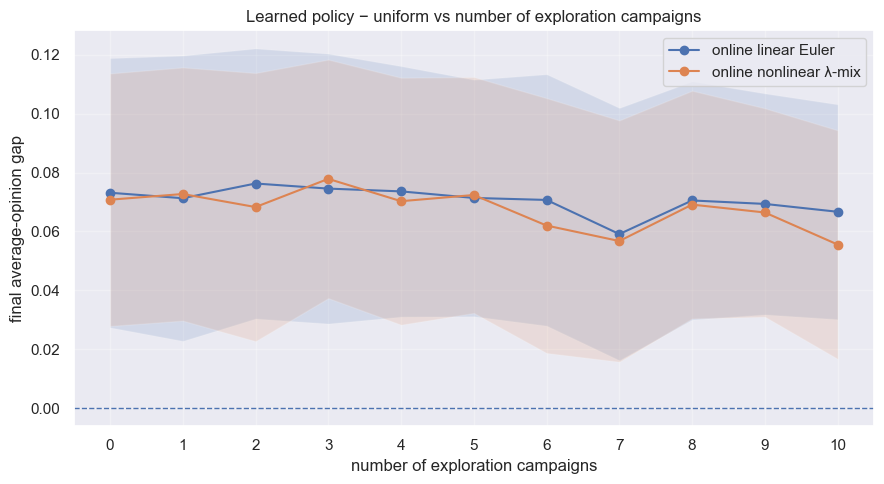

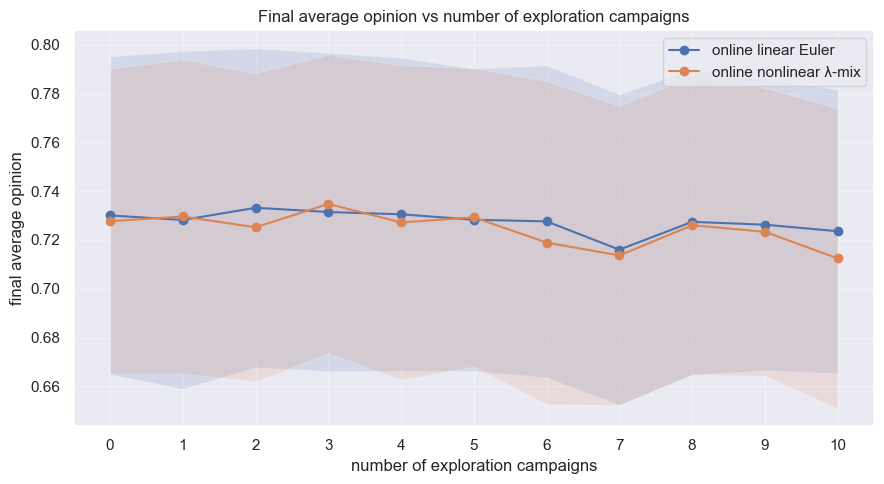

,exploration_campaigns_config,model,model_label,mean,std,count,sem,ci95
0,0,online_linear_euler,online linear Euler,0.07314,0.06998,9,0.02333,0.04572
1,0,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.07077,0.06561,9,0.02187,0.04287
2,1,online_linear_euler,online linear Euler,0.07128,0.07415,9,0.02472,0.04845
3,1,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.07270,0.06579,9,0.02193,0.04299
4,2,online_linear_euler,online linear Euler,0.07627,0.07020,9,0.02340,0.04586
5,2,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.06827,0.06967,9,0.02322,0.04552
6,3,online_linear_euler,online linear Euler,0.07454,0.07013,9,0.02338,0.04582
7,3,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.07785,0.06198,9,0.02066,0.04050
8,4,online_linear_euler,online linear Euler,0.07360,0.06512,9,0.02171,0.04254
9,4,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.07027,0.06417,9,0.02139,0.04193


In [ ]:
def mean_sem_df(df: pd.DataFrame, value_col: str, group_cols: list[str]) -> pd.DataFrame:
    out = df.groupby(group_cols)[value_col].agg(mean="mean", std="std", count="count").reset_index()
    out["sem"] = out["std"] / np.sqrt(out["count"].clip(lower=1))
    out["ci95"] = 1.96 * out["sem"].fillna(0.0)
    return out


def plot_sweep_metric(value_col: str, ylabel: str, title: str, add_zero_line: bool = False) -> pd.DataFrame:
    df = mean_sem_df(summary_df, value_col, ["exploration_campaigns_config", "model", "model_label"])
    fig, ax = plt.subplots(figsize=(9, 5))
    for model_label, sub in df.groupby("model_label"):
        sub = sub.sort_values("exploration_campaigns_config")
        x = sub["exploration_campaigns_config"].to_numpy(dtype=float)
        y = sub["mean"].to_numpy(dtype=float)
        e = sub["ci95"].to_numpy(dtype=float)
        ax.plot(x, y, marker="o", label=model_label)
        ax.fill_between(x, y - e, y + e, alpha=0.15)
    if add_zero_line:
        ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xlabel("number of exploration campaigns")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(EXPLORATION_CAMPAIGN_COUNTS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
    return df


gap_df = plot_sweep_metric(
    "model_minus_uniform_mean_end",
    "final average-opinion gap",
    "Learned policy − uniform vs number of exploration campaigns",
    add_zero_line=True,
)

mean_end_df = plot_sweep_metric(
    "mean_end",
    "final average opinion",
    "Final average opinion vs number of exploration campaigns",
)

display(gap_df.round(5))


## Best exploration count by model

In [ ]:
best_by_gap = (
    compact
    .sort_values(["model", "model_minus_uniform_mean_end"], ascending=[True, False])
    .groupby(["model", "model_label"])
    .head(3)
    [[
        "model_label",
        "exploration_campaigns_config",
        "mean_end",
        "model_minus_uniform_mean_end",
        "model_minus_oracle_mean_end",
        "win_rate_vs_uniform",
        "final_v_L1",
        "final_model_over_identity",
    ]]
)

display(best_by_gap.round(5))


,model_label,exploration_campaigns_config,mean_end,model_minus_uniform_mean_end,model_minus_oracle_mean_end,win_rate_vs_uniform,final_v_L1,final_model_over_identity
4,online linear Euler,2,0.73319,0.07627,-0.03861,0.88889,0.53734,0.21273
6,online linear Euler,3,0.73145,0.07454,-0.04034,0.77778,0.54110,0.21102
8,online linear Euler,4,0.73051,0.07360,-0.04129,0.88889,0.53806,0.20605
7,online nonlinear λ-mix,3,0.73476,0.07785,-0.03704,1.00000,0.55835,0.20226
3,online nonlinear λ-mix,1,0.72961,0.07270,-0.04218,0.88889,0.54587,0.21173
11,online nonlinear λ-mix,5,0.72928,0.07237,-0.04252,1.00000,0.55551,0.19964


## Linear vs nonlinear paired comparison

,exploration_campaigns_config,n_trials,linear_minus_nonlinear_mean_end,linear_minus_nonlinear_vs_uniform_gap,linear_win_rate
0,0,9,0.00236,0.00236,0.66667
1,1,9,-0.00143,-0.00143,0.66667
2,2,9,0.00800,0.00800,0.77778
3,3,9,-0.00330,-0.00330,0.33333
4,4,9,0.00333,0.00333,0.44444
5,5,9,-0.00100,-0.00100,0.33333
6,6,9,0.00869,0.00869,0.66667
7,7,9,0.00236,0.00236,0.44444
8,8,9,0.00141,0.00141,0.66667
9,9,9,0.00291,0.00291,0.55556


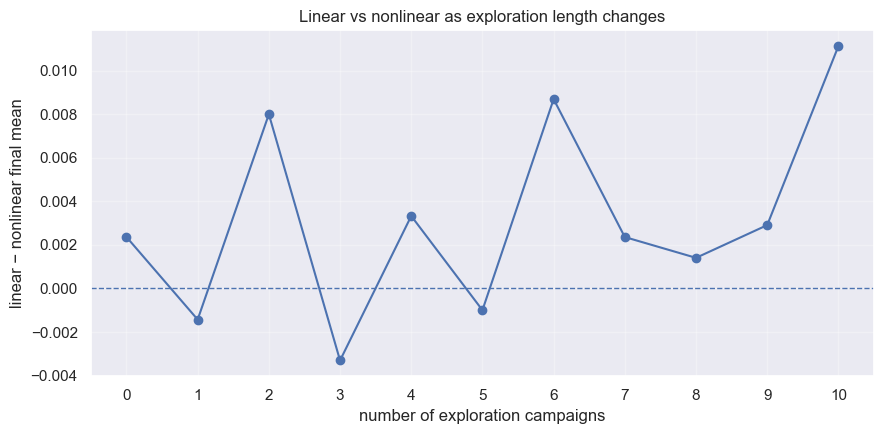

In [ ]:
paired = summary_df.pivot_table(
    index=["exploration_campaigns_config", "trial_id", "topology_seed", "initial_seed"],
    columns="model",
    values=[
        "mean_end",
        "model_minus_uniform_mean_end",
        "delta",
        "suboptimality_vs_oracle_delta",
        "final_model_over_identity",
        "final_v_L1",
        "A_MAE_final",
    ],
)
paired.columns = [f"{a}__{b}" for a, b in paired.columns]
paired = paired.reset_index()

paired["linear_minus_nonlinear_mean_end"] = paired[f"mean_end__{POLICY_LINEAR}"] - paired[f"mean_end__{POLICY_NONLINEAR}"]
paired["linear_minus_nonlinear_vs_uniform_gap"] = paired[f"model_minus_uniform_mean_end__{POLICY_LINEAR}"] - paired[f"model_minus_uniform_mean_end__{POLICY_NONLINEAR}"]
paired["linear_better_than_nonlinear"] = paired["linear_minus_nonlinear_mean_end"] > 0

paired_summary = (
    paired
    .groupby(["exploration_campaigns_config"])
    .agg(
        n_trials=("trial_id", "count"),
        linear_minus_nonlinear_mean_end=("linear_minus_nonlinear_mean_end", "mean"),
        linear_minus_nonlinear_vs_uniform_gap=("linear_minus_nonlinear_vs_uniform_gap", "mean"),
        linear_win_rate=("linear_better_than_nonlinear", "mean"),
    )
    .reset_index()
)

display(paired_summary.round(5))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(paired_summary["exploration_campaigns_config"], paired_summary["linear_minus_nonlinear_mean_end"], marker="o")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_xlabel("number of exploration campaigns")
ax.set_ylabel("linear − nonlinear final mean")
ax.set_title("Linear vs nonlinear as exploration length changes")
ax.set_xticks(EXPLORATION_CAMPAIGN_COUNTS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Fit diagnostics vs exploration count

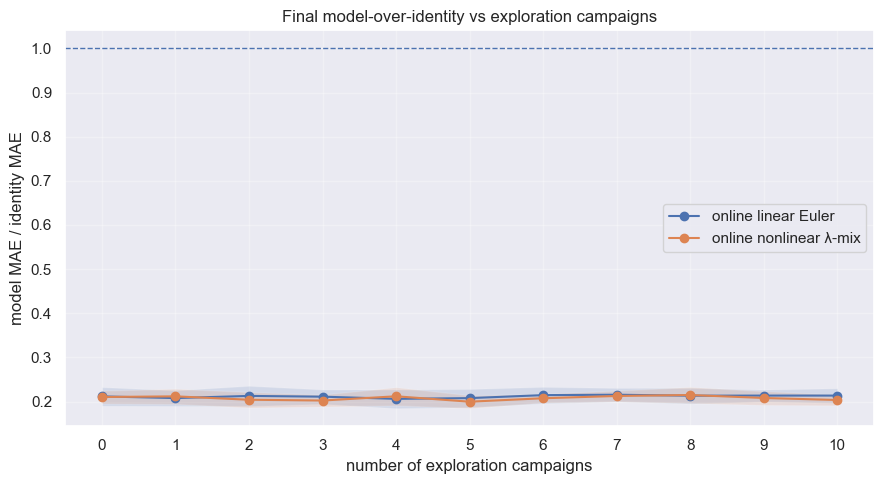

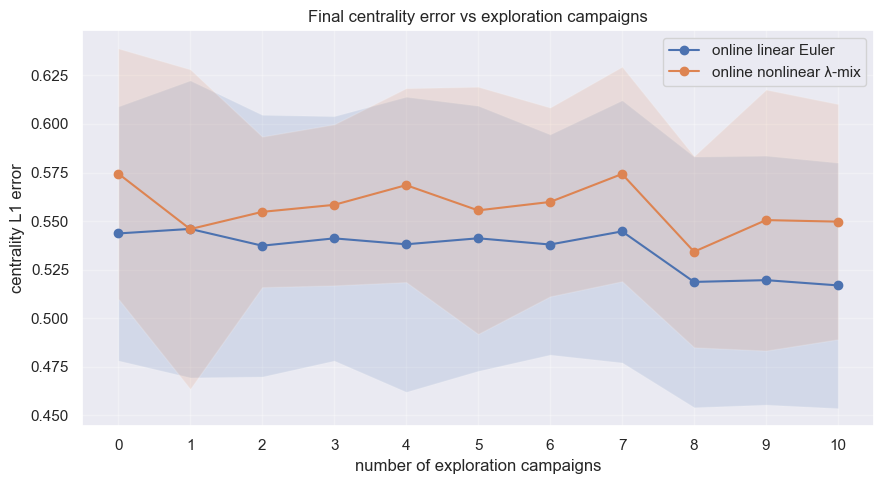

In [ ]:
if not summary_df.empty:
    for value_col, ylabel, title, add_zero in [
        ("final_model_over_identity", "model MAE / identity MAE", "Final model-over-identity vs exploration campaigns", True),
        ("final_v_L1", "centrality L1 error", "Final centrality error vs exploration campaigns", False),
    ]:
        df = mean_sem_df(summary_df, value_col, ["exploration_campaigns_config", "model", "model_label"])
        fig, ax = plt.subplots(figsize=(9, 5))
        for model_label, sub in df.groupby("model_label"):
            sub = sub.sort_values("exploration_campaigns_config")
            x = sub["exploration_campaigns_config"].to_numpy(dtype=float)
            y = sub["mean"].to_numpy(dtype=float)
            e = sub["ci95"].to_numpy(dtype=float)
            ax.plot(x, y, marker="o", label=model_label)
            ax.fill_between(x, y - e, y + e, alpha=0.15)
        if add_zero and value_col == "final_model_over_identity":
            ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_xlabel("number of exploration campaigns")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_xticks(EXPLORATION_CAMPAIGN_COUNTS)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()


## Average-opinion trajectories for selected exploration counts

To avoid 11 separate trajectory plots, this section only shows `SELECT_EXPLORATION_COUNTS_FOR_TRAJECTORIES` from the config cell.

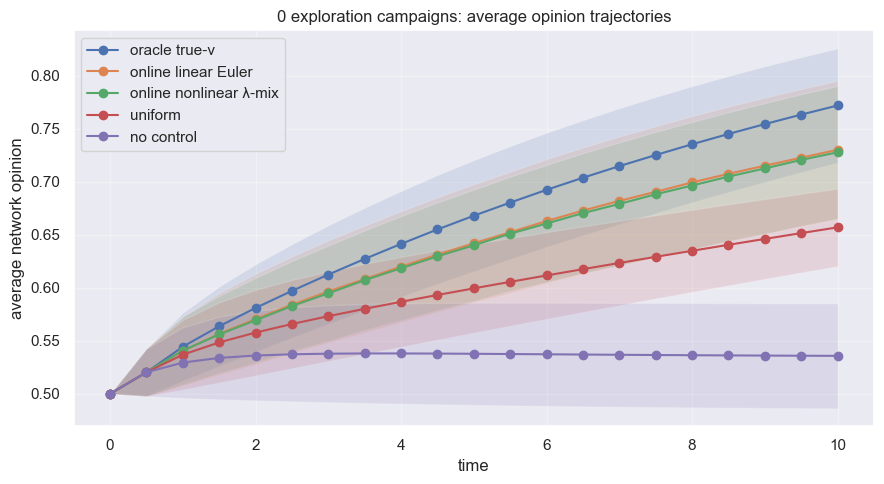

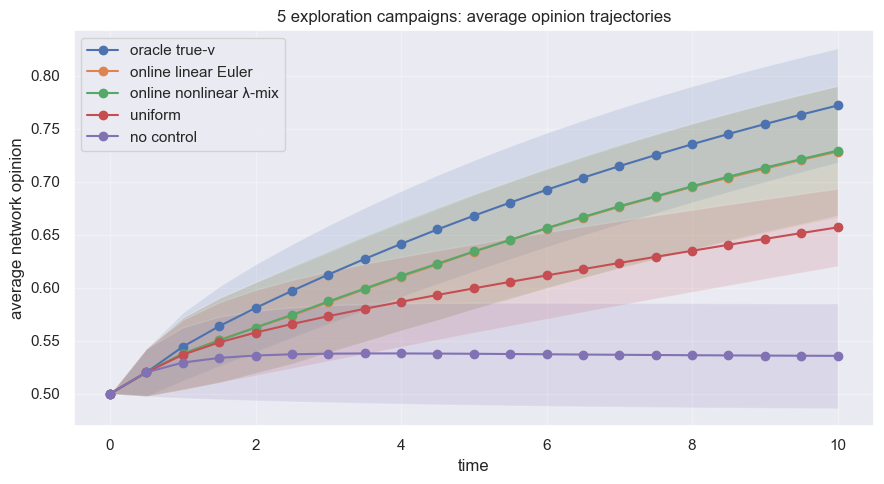

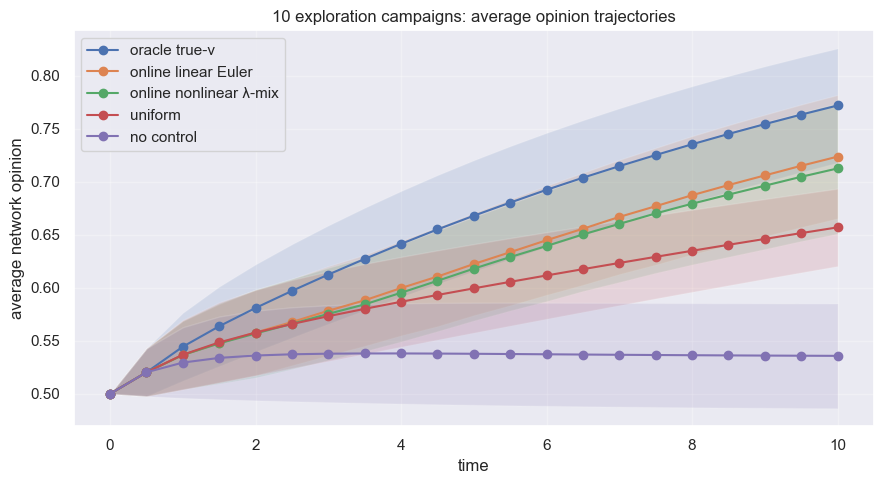

In [ ]:
def plot_mean_trajectories_for_exploration_counts(metric: str = "mean_opinion") -> None:
    for exploration_count in SELECT_EXPLORATION_COUNTS_FOR_TRAJECTORIES:
        df = trajectory_df[
            (trajectory_df["exploration_campaigns_config"] == exploration_count)
            & (trajectory_df["policy"].isin(PLOT_POLICIES))
        ].copy()
        if df.empty:
            continue
        fig, ax = plt.subplots(figsize=(9, 5))
        for policy in PLOT_POLICIES:
            sub = df[df["policy"] == policy]
            grouped = sub.groupby("time")[metric]
            mean = grouped.mean()
            count = grouped.count()
            sem = grouped.std(ddof=1) / np.sqrt(count.clip(lower=1))
            sem = sem.fillna(0.0)
            x = mean.index.to_numpy(dtype=float)
            y = mean.to_numpy(dtype=float)
            e = sem.to_numpy(dtype=float)
            ax.plot(x, y, marker="o", label=POLICY_LABELS.get(policy, policy))
            ax.fill_between(x, y - 1.96 * e, y + 1.96 * e, alpha=0.15)
        ax.set_title(f"{exploration_count} exploration campaigns: average opinion trajectories")
        ax.set_xlabel("time")
        ax.set_ylabel("average network opinion")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()


plot_mean_trajectories_for_exploration_counts("mean_opinion")


## Topology × initial-state heatmaps for selected exploration counts

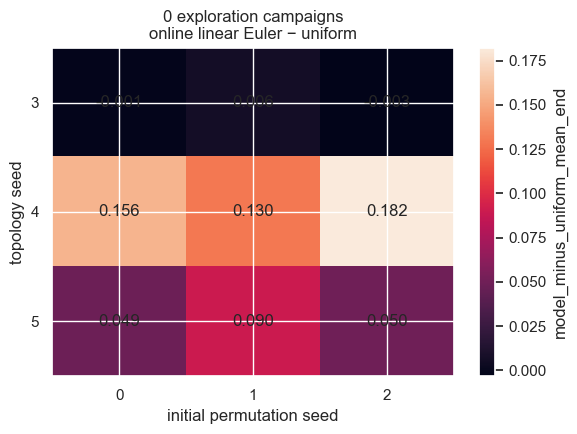

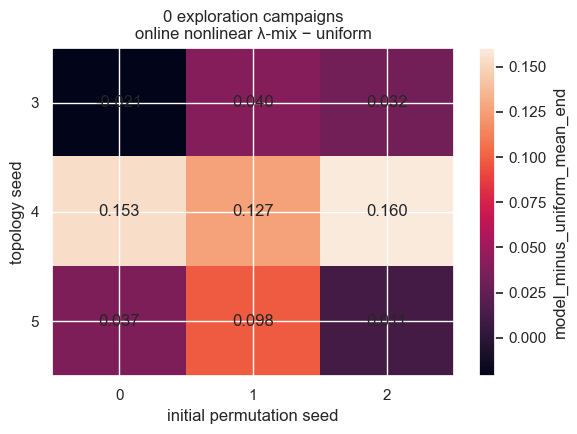

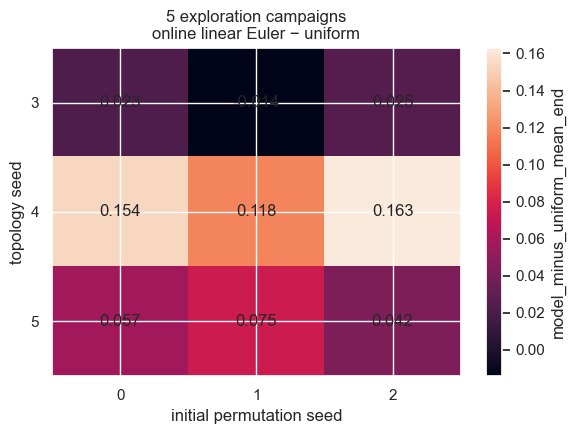

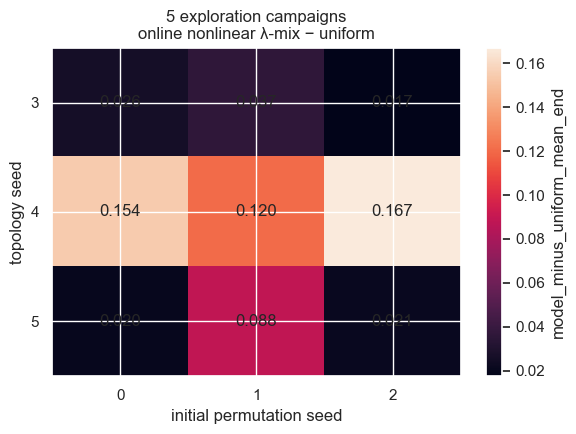

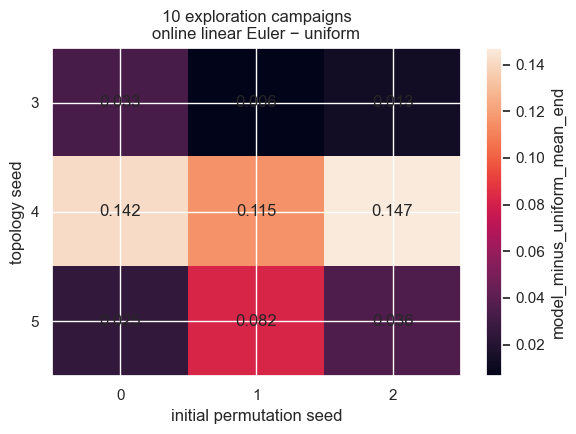

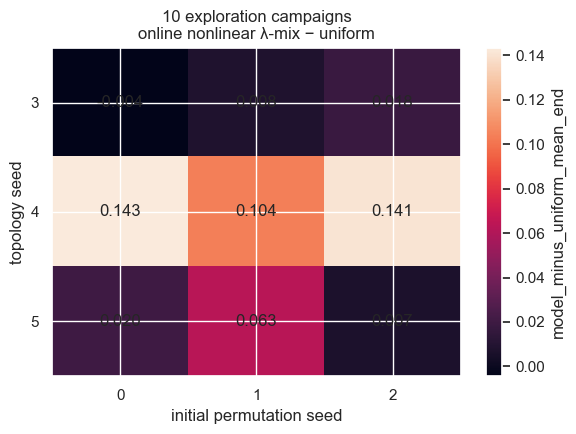

In [ ]:
def plot_heatmap_for_model_exploration_count(exploration_count: int, model: str, value_col: str = "model_minus_uniform_mean_end") -> None:
    sub = summary_df[(summary_df["exploration_campaigns_config"] == exploration_count) & (summary_df["model"] == model)].copy()
    if sub.empty:
        return
    table = sub.pivot(index="topology_seed", columns="initial_seed", values=value_col)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    im = ax.imshow(table.values, aspect="auto")
    ax.set_title(f"{exploration_count} exploration campaigns\n{POLICY_LABELS[model]} − uniform")
    ax.set_xlabel("initial permutation seed")
    ax.set_ylabel("topology seed")
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            val = table.values[i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center")
    fig.colorbar(im, ax=ax, label=value_col)
    plt.tight_layout()
    plt.show()


for exploration_count in HEATMAP_EXPLORATION_COUNTS:
    plot_heatmap_for_model_exploration_count(exploration_count, POLICY_LINEAR)
    plot_heatmap_for_model_exploration_count(exploration_count, POLICY_NONLINEAR)


## Selected-trial diagnostic

Selected exploration count: 0
Selected trial: laplacian|topo=3|init=0


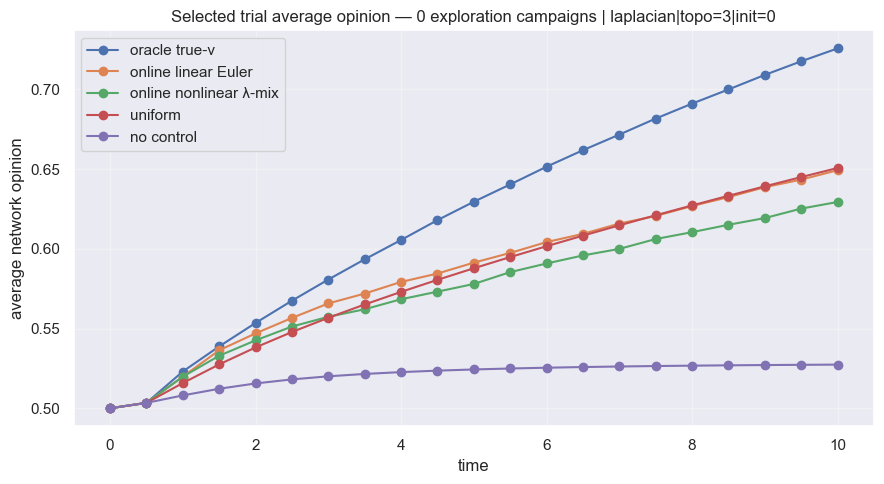

,dynamics,topology_seed,initial_seed,trial_id,model,model_label,delta,delta_oracle,delta_uniform,delta_nocontrol,suboptimality_vs_oracle_delta,model_minus_uniform_delta,model_minus_nocontrol_delta,mean_end,mean_oracle_end,mean_uniform_end,mean_nocontrol_end,model_minus_oracle_mean_end,model_minus_uniform_mean_end,model_minus_nocontrol_mean_end,max_v_L1,final_v_L1,A_MAE_final,A_Fro_final,final_train_mae,final_identity_mae,final_model_over_identity,final_n_pairs,total_fit_time_sec,condition,condition_label,condition_trial_id,exploration_campaigns_config,fit_max_steps_config,fit_mae_stop_config
0,laplacian,3,0,laplacian|topo=3|init=0,online_linear_euler,online linear Euler,0.34726,0.26638,0.34879,0.47195,0.08089,-0.00153,-0.12469,0.64932,0.72572,0.65071,0.52737,-0.07640,-0.00138,0.12195,0.53634,0.47827,0.08510,1.93112,0.00049,0.00179,0.27320,200,1.31037,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,0,1000,0.0005
1,laplacian,3,0,laplacian|topo=3|init=0,online_nonlinear_lambda_mix,online nonlinear λ-mix,0.37170,0.26638,0.34879,0.47195,0.10532,0.02291,-0.10025,0.62940,0.72572,0.65071,0.52737,-0.09633,-0.02131,0.10202,0.54501,0.53867,0.08834,1.98064,0.00037,0.00176,0.20919,200,3.32780,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,0,1000,0.0005


: 

In [ ]:
SELECT_EXPLORATION_COUNT = EXPLORATION_CAMPAIGN_COUNTS[0]
SELECT_TOPOLOGY_SEED = TOPOLOGY_SEEDS[0]
SELECT_INITIAL_SEED = INITIAL_PERMUTATION_SEEDS[0]
SELECT_TRIAL_ID = f"{DYNAMICS}|topo={SELECT_TOPOLOGY_SEED}|init={SELECT_INITIAL_SEED}"
print("Selected exploration count:", SELECT_EXPLORATION_COUNT)
print("Selected trial:", SELECT_TRIAL_ID)

sel = trajectory_df[
    (trajectory_df["exploration_campaigns_config"] == SELECT_EXPLORATION_COUNT)
    & (trajectory_df["trial_id"] == SELECT_TRIAL_ID)
].copy()
fig, ax = plt.subplots(figsize=(9, 5))
for policy in PLOT_POLICIES:
    sub = sel[sel["policy"] == policy]
    ax.plot(sub["time"], sub["mean_opinion"], marker="o", label=POLICY_LABELS.get(policy, policy))
ax.set_title(f"Selected trial average opinion — {SELECT_EXPLORATION_COUNT} exploration campaigns | {SELECT_TRIAL_ID}")
ax.set_xlabel("time")
ax.set_ylabel("average network opinion")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

display(summary_df[(summary_df["exploration_campaigns_config"] == SELECT_EXPLORATION_COUNT) & (summary_df["trial_id"] == SELECT_TRIAL_ID)].round(5))
